# ADSC 3040 Project 
## Investment Portfolio Optimization
Date: December 4, 2025

Prepared by:
1. Mint Thai - T00762325
2. Cynthia Urrutia - T00735328

# Table of Contents

1. [Introduction](#Introduction)
   - [Exploratory Data Analysis](#Exploratory-Data-Analysis)
2. [Research Questions and Objectives](#Research-Questions-and-Objectives)
3. [Model Construction](#Model-Construction)
   - [Optimization Model Construction](#Optimization-Model-Construction)
   - [Sensitivity Analysis Construction](#Sensitivity-Analysis-Construction)
4. [Results](#Results)
   - [Investor Profiles](#Investor-Profiles)
   - [Portfolio Optimization](#Portfolio-Optimization)
   - [Sensitivity Analysis](#Sensitivity-Analysis)
5. [Conclusion](#Conclusion)
6. [References](#References)
7. [Appendix](#Appendix)

In [121]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [122]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


<div style="page-break-before: always;"></div>


# Introduction

In finance, high-return assets often entail high volatility or move closely together, making it challenging to decide which stocks to include in a portfolio that balances return, risk, and diversification. This project addresses that problem by developing a model that optimizes expected returns while managing risk, subject to constraints around risk tolerance, diversification, and correlation.

Using historical S&P 500 pricing data from November 2020 to November 2025, we compute weighted returns, volatility, and correlation measures that feed into the optimization model. The final portfolio solutions are generated through linear optimization and evaluated across three investor profiles: Aggressive, Balanced, and Conservative. Each is defined by different constraint levels.

The analysis includes data processing, exploratory data analysis, the construction of the optimization model, and sensitivity testing to understand how constraint choices affect portfolio outcomes.

## Exploratory Data Analysis

Based on pricing data scraped from Yahoo Finance over the last 5 years, the whole dataset contains approximately half a million rows covering all 503 S&P 500 companies across 11 industries. The fields consist of price data (open, close, high, low), trading volume, ticker symbol, security name, sector, and index weight.

To simplify the analysis and reduce computational demand, a representative subset of the index is selected by choosing the three highest-weighted companies from each sector. This results in 33 decision variables, collectively representing 49.9% of the overall index. The individual company weights within this subset are shown in the bar chart below.

In [123]:
sp500_subset.head()

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [ ]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

In [ ]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

In [ ]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

In [127]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()

Total sum of weights in S&P 500 subset: 49.96%


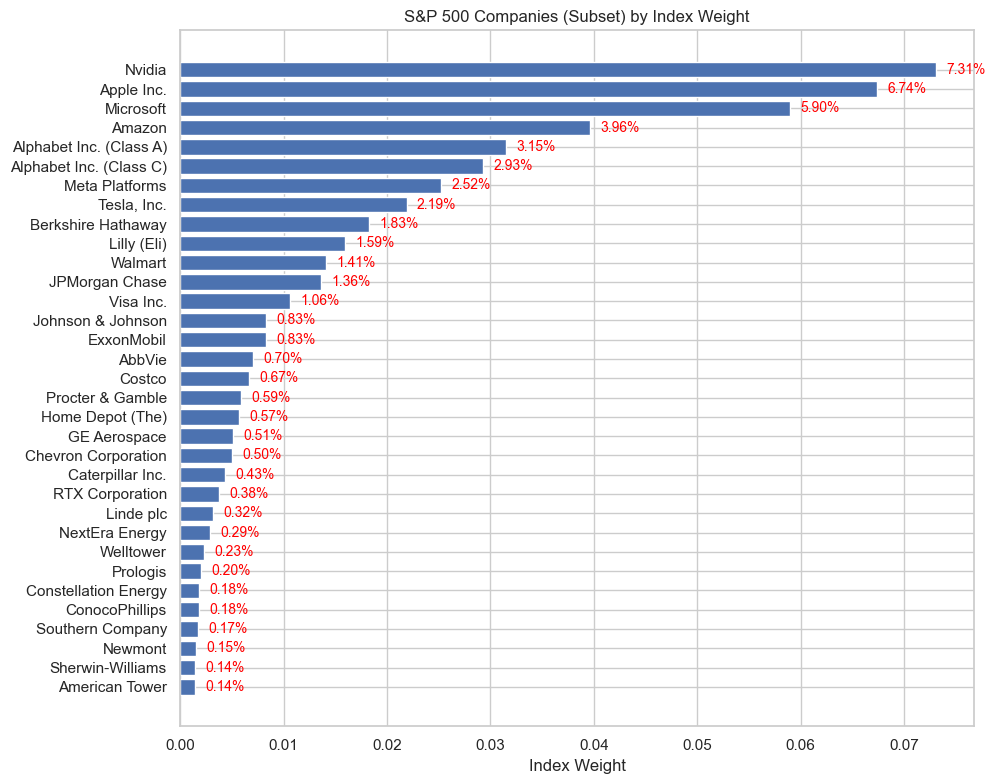

In [152]:
# Plot all S&P 500 Subset companies by weight with % labels

print(f"Total sum of weights in S&P 500 subset: {sum_weights*100:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()

In [129]:
# Calculate daily returns and log returns
import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])

Annual returns and standard deviations (used as measures of performance and risk) are computed using weighted metrics based on the following distribution across the five-year window:

| 2020 | 2021 |  2022 |  2023 |  2024 |  2025 |
|------|------|-------|-------|-------|-------|
|  5%  |  5%  |  10%  |  20%  |  30%  |  30%  |

A summary of these calculations is shown in the table below. The weighting scheme accounts for the unusual market conditions during the pandemic years (2020–2021) and places greater emphasis on recent years, when the AI-driven rally materially influenced market dynamics.

In [130]:
# Weighted Summary Statistics

import numpy as np
import pandas as pd

# Assign Year + Weights
sp500_subset2["Year"] = sp500_subset2["Date"].dt.year
year_weights = {2020:0.05, 2021:0.05, 2022:0.10, 2023:0.20, 2024:0.30, 2025:0.30}
sp500_subset2["YearWeight"] = sp500_subset2["Year"].map(year_weights)

# ---- Weighted Functions ----

def weighted_mean(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    return np.average(v, weights=w)

def weighted_sd(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    mean_w = np.average(v, weights=w)
    var_w = np.average((v - mean_w)**2, weights=w)
    return np.sqrt(var_w)

# ---- Grouped weighted calculations ----

weighted_summary = (
    sp500_subset2
        .groupby("Symbol")
        .apply(
            lambda g: pd.Series({
                "W_Daily_Return": weighted_mean(g["Return"], g["YearWeight"]),
                "W_Daily_LogReturn": weighted_mean(g["LogReturn"], g["YearWeight"]),
                "W_SD_Return": weighted_sd(g["Return"], g["YearWeight"]),
                "W_SD_LogReturn": weighted_sd(g["LogReturn"], g["YearWeight"])
            }),
            include_groups=False
        )
        .reset_index()
)

# ---- Annualizations ----

weighted_summary["W_Annual_LogReturn"] = weighted_summary["W_Daily_LogReturn"] * 252
weighted_summary["W_Annual_Return"] = np.exp(weighted_summary["W_Annual_LogReturn"]) - 1

weighted_summary["W_Annual_SD"] = weighted_summary["W_SD_Return"] * np.sqrt(252)
weighted_summary["W_Annual_LogSD"] = weighted_summary["W_SD_LogReturn"] * np.sqrt(252)

# ---- Summary ----

weighted_summary = weighted_summary[[
    "Symbol",
    "W_Daily_Return",
    "W_Annual_Return",
    "W_SD_Return",
    "W_Annual_SD",
]]

weighted_summary.head()

,Symbol,W_Daily_Return,W_Annual_Return,W_SD_Return,W_Annual_SD
0,AAPL,0.000893,0.205531,0.017461,0.277187
1,ABBV,0.000871,0.211540,0.014721,0.233689
2,AMT,-0.000058,-0.047029,0.016336,0.259325
3,AMZN,0.000927,0.191257,0.021554,0.342156
4,BRK-B,0.000693,0.173847,0.010636,0.168835


The box plots of annual return and annual standard deviation show clear differences in performance and risk across sectors. Higher-return sectors generally exhibit higher volatility, while more defensive sectors offer lower returns with more stable behavior. For example, the Information Technology sector shows some of the highest returns but also noticeably higher volatility. In contrast, Consumer Staples display low, consistent returns with very little volatility, offering stability but limited growth potential. Consumer Discretionary falls in the middle, with moderate returns but a wide spread in volatility. Some companies behave like growth stocks with higher risk (e.g., Tesla), while others are much more stable, making the sector overall quite mixed.

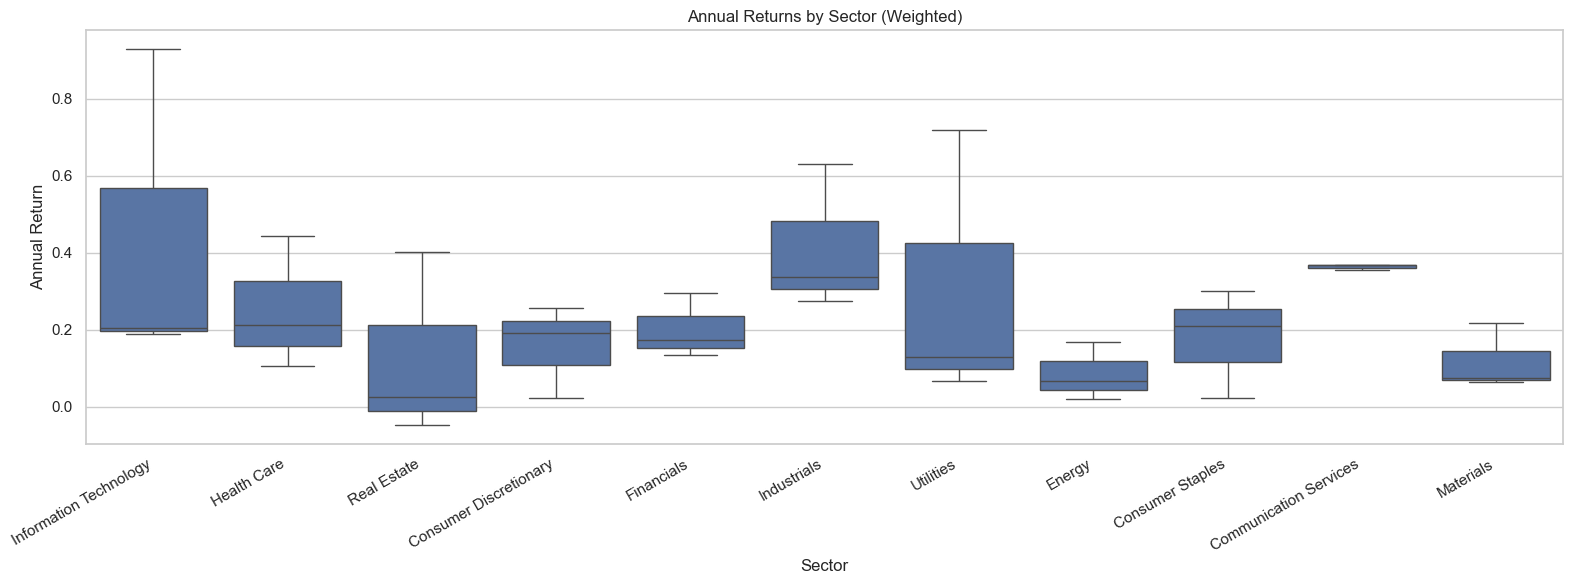

In [131]:
# Boxplot of annual return by sector

import seaborn as sns
import matplotlib.pyplot as plt

# Attach Sector to weighted summary for boxplot
returns_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=returns_df, x="Sector", y="W_Annual_Return")
plt.xticks(rotation=30, ha='right')
plt.title("Annual Returns by Sector (Weighted)")
plt.xlabel("Sector")
plt.ylabel("Annual Return")
plt.tight_layout()
plt.show()

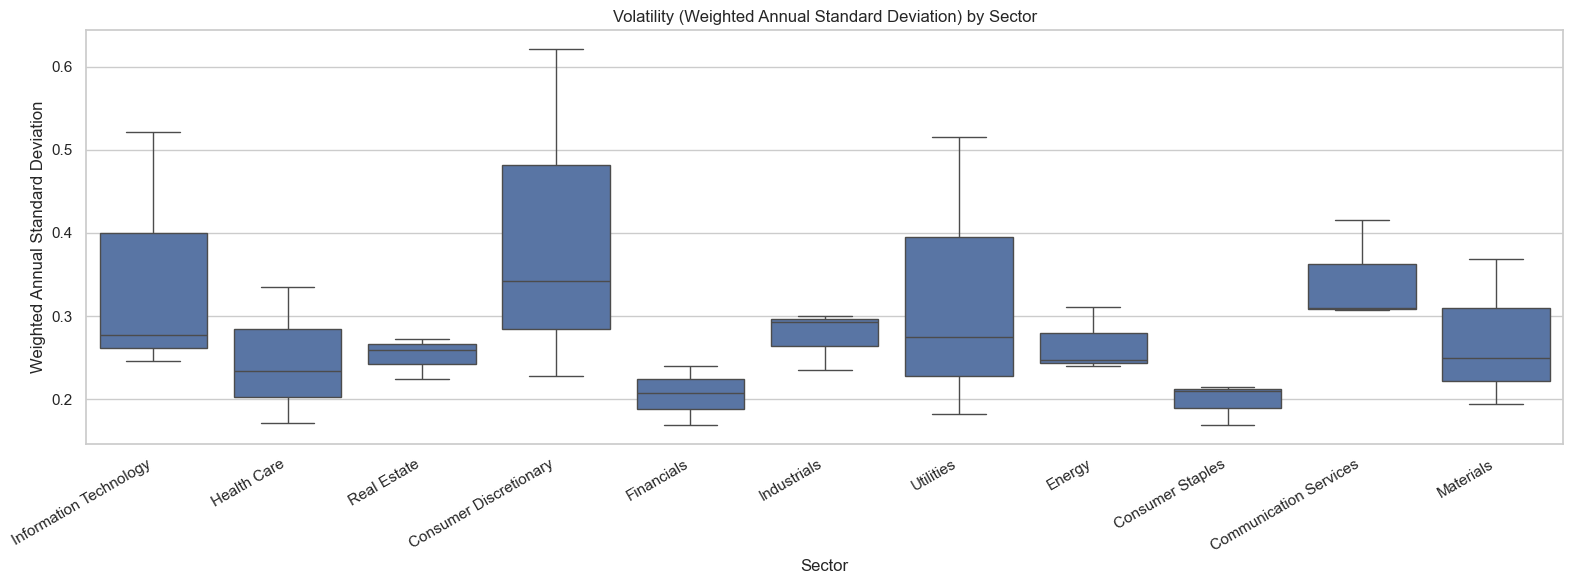

In [132]:
# Boxplot of volatility (SD of returns) by sector

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Sector column exists in weighted_summary
vol_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=vol_df, x="Sector", y="W_Annual_SD")
plt.xticks(rotation=30, ha='right')
plt.title("Volatility (Weighted Annual Standard Deviation) by Sector")
plt.xlabel("Sector")
plt.ylabel("Weighted Annual Standard Deviation")
plt.tight_layout()
plt.show()


Additionally, across the 33 selected stocks, there is substantial dispersion in risk–return characteristics. A small group of companies (NVDA, CEG, GE, and LLY) stands out as the strongest performers, while most stocks cluster in the lower-risk, lower-return range, as shown in the stock-level risk–return scatter plot. A few stocks, such as TSLA, show high volatility without corresponding returns.

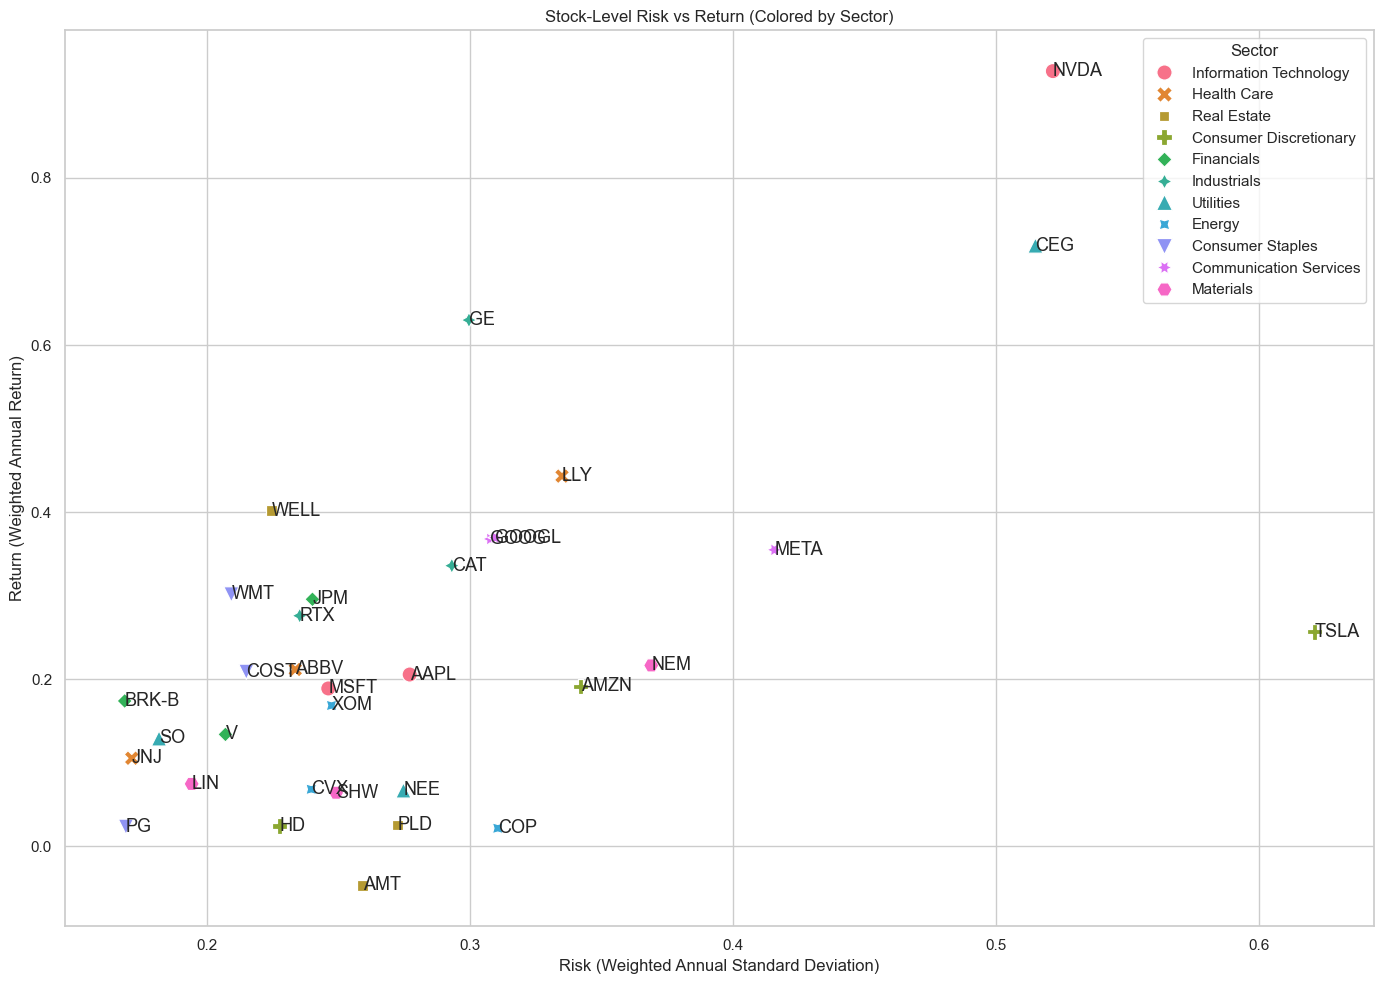

In [133]:
# Risk-Return Map By Stock
import seaborn as sns
import matplotlib.pyplot as plt

# Attach sector for coloring
df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(14, 10))  # Larger figure size

sns.scatterplot(
    data=df,
    x="W_Annual_SD",
    y="W_Annual_Return",
    hue="Sector",
    style="Sector",
    s=120  # Larger marker size
 )

# Label each point with stock symbol
for _, row in df.iterrows():
    plt.text(
        row["W_Annual_SD"],  # Use correct x axis
        row["W_Annual_Return"],
        row["Symbol"],
        fontsize=13,
        ha='left',
        va='center'
    )

plt.xlabel("Risk (Weighted Annual Standard Deviation)")
plt.ylabel("Return (Weighted Annual Return)")
plt.title("Stock-Level Risk vs Return (Colored by Sector)")
plt.tight_layout()
plt.show()

An industry-level correlation matrix further highlights diversification challenges. Most sectors demonstrate positive correlations with one another. In contrast, only a few, primarily in Energy and Utilities, show near-zero correlations. This confirms the structural difficulty of achieving meaningful diversification within the S&P 500.

Additional visualizations are included in the appendix.

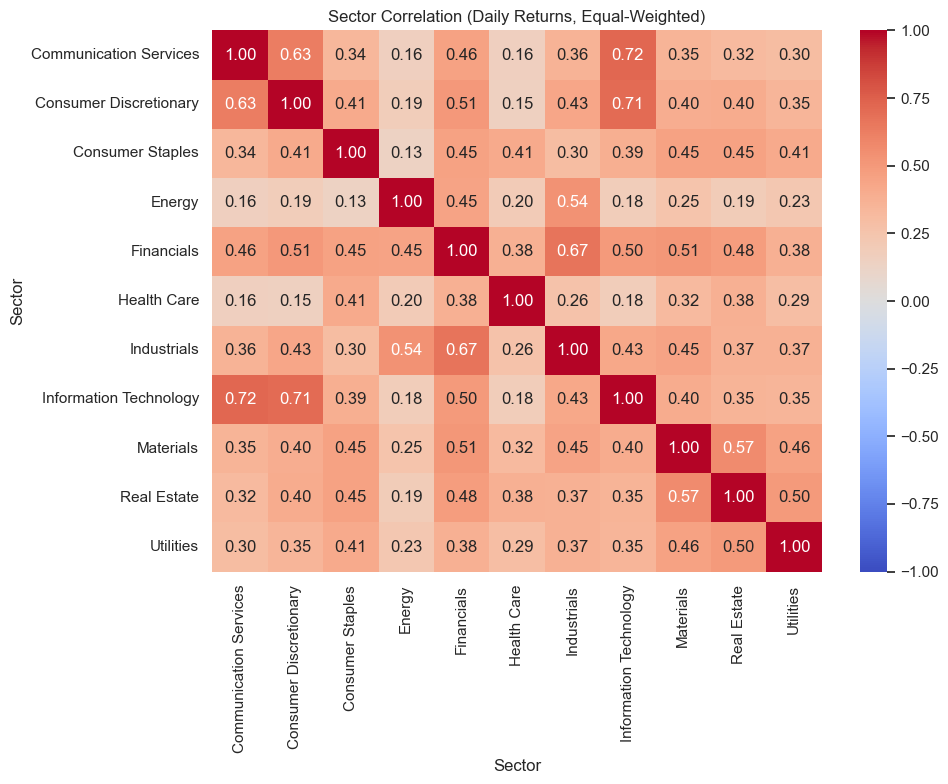

In [134]:
# Sector daily return (equal-weight across stocks)
ret_log = sp500_subset2.dropna(subset=["Return"])

sector_daily_log = (
    ret_log.groupby(["Date", "Sector"])["Return"]
           .mean()
           .unstack("Sector")
           .sort_index()
)

sector_corr_log = sector_daily_log.corr()

import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(sector_corr_log, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Sector Correlation (Daily Returns, Equal-Weighted)")
plt.tight_layout()
plt.show()

In [135]:
# ----------------------------------------
# 1. Build ticker → sector mapping
# ----------------------------------------
sector_map = (
    sp500_subset[["Symbol", "Sector"]]
    .drop_duplicates(subset="Symbol")
    .set_index("Symbol")["Sector"]
)

# ----------------------------------------
# 2. Add Sector into weighted summary
# ----------------------------------------
weighted_summary = weighted_summary.merge(
    sector_map.rename("Sector"),
    on="Symbol",
    how="left"
)

# ----------------------------------------
# 3. Build sector-level correlation score
# ----------------------------------------
sector_corr_score = sector_corr_log.mean(axis=1)

# ----------------------------------------
# 4. Convert to per-ticker correlation score (length = 33)
# ----------------------------------------
corr_score_ticker = weighted_summary["Sector"].map(sector_corr_score)
corr_score = corr_score_ticker.values
np.save("corr_score.npy", corr_score)

print("corr_score shape =", corr_score.shape)

corr_score shape = (33,)


# Research Questions and Objectives

The main research questions include:
- How can weights be allocated across S&P 500 subset assets to maximize expected returns while managing risk and maintaining diversification?
- How do volatility limits, max weight constraints, and correlation rules affect the optimized portfolio?
- How do results differ across Aggressive, Balanced, and Conservative investor profiles?
- Which constraint(s) have the most substantial impact on return?

To answer these research questions, the project focuses on two core objectives. The first objective is to develop a linear optimization model that maximizes expected returns while satisfying five key constraints related to volatility, correlation, concentration limits, and overall diversification. This model is applied across three investor profiles to generate portfolios containing asset allocation under different risk criteria. A convex optimization framework is used because it provides a reliable way to find a single global optimum and is well-suited for portfolio allocation problems.

The second objective is to conduct a sensitivity analysis of the key constraints to assess how the model responds when limits are tightened or relaxed, and to identify plateau points at which additional risk or weight no longer improves returns.

# Model Construction

## Optimization Model Construction

The portfolio in this project is built using a modified version of the Markowitz optimization model because the traditional mean–variance setup focuses only on return and volatility. By imposing constraints on maximum weight and correlation, the model better reflects practical investment considerations such as diversification and risk control.

The model’s objective is to maximize total expected return, subject to all the constraints above.

$$
\begin{aligned}
\text{maximize} \quad & \mu^\top w \\[6pt]
\text{subject to} \quad 
& \sum_{i=1}^n w_i = 1, 
\quad\text{(Full investment)} \\[6pt]
& w_i \ge 0 \quad \forall i, 
\quad\text{(Long-only constraint)} \\[6pt]
& w_i \le \text{MAX\_WEIGHT} \quad \forall i, 
\quad\text{(Concentration limit)} \\[6pt]
& w^\top \Sigma w \le \sigma_{\max}^2, 
\quad\text{(Risk constraint)} \\[6pt]
& w^\top C w \le \text{CorrScore}_{\max},
\quad\text{(Diversification constraint)}
\end{aligned}
$$

**Where:**

- $w$ — vector of portfolio weights  
- $\mu$ — vector of expected annualized returns  
- $\Sigma$ — covariance matrix of asset returns  
- $C$ — correlation matrix derived from $\Sigma$  
- $\sigma_{\max}$ — maximum allowed portfolio volatility  
- $\text{MAX\_WEIGHT}$ — maximum allocation to any single asset  
- $\text{CorrScore}_{\max}$ — maximum allowable correlation score (diversification constraint)

The implementation relies on the CVXPY library to solve the convex optimization constraints, enabling the computation of an efficient global optimum. The model is initialized using the expected annual returns and the annual covariance matrix for the selected list of tickers.

## Sensitivity Analysis Construction

Sensitivity analysis is conducted on the three key constraints to evaluate how changes in risk, diversification, and concentration limits affect the optimized portfolio:

- **Maximum Volatility** $(\sigma_{\max})$ — portfolio risk cap  
- **Maximum Correlation Score** $(\text{CorrScore}_{\max})$ — diversification constraint  
- **Maximum Asset Weight** $(\text{MAX\_WEIGHT})$ — concentration limit  

Each parameter is varied across a predefined grid while the remaining two are held constant at the baseline settings:

$$
\sigma_{\max} = 0.50, \quad \text{CorrScore}_{\max} = 0.55, \quad \text{MAX\_WEIGHT} = 0.75.
$$

For each grid value, the model attempts to re-solve the optimization problem.

To identify the point at which further relaxation of a constraint no longer improves performance, a plateau condition is used throughout the analysis:

$$
\text{max\_return} - R(v) \le \text{tol},
$$

where **tol** is a small numerical tolerance (set to $10^{-4}$) that determines when additional increases in expected return become negligible.

In [136]:
# ============================================================
# EXPORT weighted_summary2 for optimization in VS Code
# ============================================================

mu_annual = weighted_summary["W_Annual_Return"].values
sigma_annual = weighted_summary["W_Annual_SD"].values
tickers = weighted_summary["Symbol"].tolist()

np.save("mu_annual.npy", mu_annual)
np.save("sigma_annual.npy", sigma_annual)
pd.Series(tickers).to_csv("tickers.csv", index=False)

In [ ]:
w = weighted_summary["W_Annual_SD"]

print(f"Weighted Annual SD -- Min: {w.min():.4f}, Median: {w.median():.4f}, Max: {w.max():.4f}")


In [138]:
# Export sp500_subset2 to CSV
sp500_subset2.to_csv("sp500_subset2.csv", index=False)

In [ ]:
## UPDATED MARKOWITZ MODEL (PORTFOLIO RISK CAL UPDATED)

import numpy as np
import pandas as pd
import cvxpy as cp

# ----------------------------------------------------
# 1. LOAD RETURN, COVARIANCE, TICKERS
# ----------------------------------------------------

mu = np.load("../notebooks/mu_annual.npy")        # (n,)
cov = np.load("../notebooks/cov_annual.npy")      # (n, n)
tickers = pd.read_csv("../notebooks/tickers.csv", header=None)[0].astype(str).tolist()

# FIX: drop the index row if it exists
if tickers[0].strip() == "0":
    tickers = tickers[1:]

n = len(mu)

# Ensure covariance is valid
cov = 0.5 * (cov + cov.T)
eps = 1e-8
cov = cov + eps * np.eye(n)

assert cov.shape == (n, n), f"Expected {n}x{n} covariance, got {cov.shape}"

# --- GLOBAL CONSTRAINTS ---

MAX_WEIGHT = 0.75  # <-- applies to ALL profiles

# ----------------------------------------------------
# 2. PROFILE-SPECIFIC PARAMETERS
# ----------------------------------------------------

profile_params = {
    "Aggressive": {
        "max_vol": 0.45,
        "max_corr_score": 0.55,
    },
    "Balanced": {
        "max_vol": 0.25,
        "max_corr_score": 0.45,
    },
    "Conservative": {
        "max_vol": 0.18,
        "max_corr_score": 0.35,
    }
}

# ----------------------------------------------------
# 3. BUILD CORRELATION MATRIX
# ----------------------------------------------------
sigma_vec = np.sqrt(np.diag(cov))        

with np.errstate(divide="ignore", invalid="ignore"):
    denom = np.outer(sigma_vec, sigma_vec)
    corr_mat = cov / denom
    corr_mat[~np.isfinite(corr_mat)] = 0.0

np.fill_diagonal(corr_mat, 1.0)
corr_mat = 0.5 * (corr_mat + corr_mat.T)
corr_mat = corr_mat + eps * np.eye(n)

# ----------------------------------------------------
# 4. OPTIMIZER
# ----------------------------------------------------
def max_return_low_corr_markowitz(mu, cov, corr_mat,
                                  max_vol,
                                  max_corr_score,
                                  max_weight): 

    n = len(mu)
    w = cp.Variable(n)

    port_var = cp.quad_form(w, cov)
    corr_score_expr = cp.quad_form(w, corr_mat)

    objective = cp.Maximize(mu @ w) ## Objective Function

    constraints = [
        cp.sum(w) == 1, # Full Investment
        w >= 0,         # No Short Selling
        w <= max_weight, # Max Weight Constraint
        port_var <= max_vol**2, # Max Volatility Constraint
        corr_score_expr <= max_corr_score, # Max Correlation Score Constraint   
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if (w.value is None) or (prob.status not in ["optimal", "optimal_inaccurate"]):
        raise RuntimeError(f"Quadratic optimization failed: {prob.status}")

    w_opt = np.array(w.value).flatten()
    port_return = float(mu @ w_opt)
    port_vol = float(np.sqrt(w_opt @ cov @ w_opt))
    port_corr = float(w_opt @ corr_mat @ w_opt)

    return w_opt, port_return, port_vol, port_corr


# ----------------------------------------------------
# 5. RUN OPTIMIZER
# ----------------------------------------------------
results = {}

for profile, params in profile_params.items():

    w, ret, vol, corr_q = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=params["max_vol"],
        max_corr_score=params["max_corr_score"],
        max_weight=MAX_WEIGHT   # <-- global constraint
    )

    df = pd.DataFrame({"Ticker": tickers, "Weight": w}).sort_values("Weight", ascending=False).round({"Weight": 4})

    print("\n=========================================")
    print(f"PORTFOLIO OPTIMIZATION – {profile}")
    print("=========================================")
    print(f"Return (mu^T w):          {ret: .2%}")
    print(f"Volatility (sqrt wΣw):    {vol: .2%} (limit {params['max_vol']: .0%})")
    print(f"CorrScore (w^T C w):      {corr_q: .2f} (limit {params['max_corr_score']: .2f})\n")

    print(df[df["Weight"] > 0.001])

    results[profile] = {
        "weights": w,
        "return": ret,
        "vol": vol,
        "corr": corr_q
    }

In [140]:
# ----------------------------------------------------
# SENSITIVITY ANALYSIS
# ----------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Wrapper function to handle infeasible cases

def safe_optimize(max_vol, max_corr_score, max_weight):
    """
    Wrapper around max_return_low_corr_markowitz that
    returns NaNs instead of blowing up when the problem is infeasible.
    """
    try:
        w, ret, vol, corr_q = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=max_vol,
            max_corr_score=max_corr_score,
            max_weight=max_weight
        )
        return w, ret, vol, corr_q
    except Exception:
        n = len(mu)
        return np.full(n, np.nan), np.nan, np.nan, np.nan


# ----------------------------------------------------
# GLOBAL RANGES FOR THE THREE KNOBS
# ----------------------------------------------------
max_vol_grid    = np.linspace(0.15, 0.5, 20)   # risk cap
max_corr_grid   = np.linspace(0.10, 1, 20)   # corr_score cap
max_weight_grid = np.linspace(0.20, 1, 20)   # max_weight cap

# A baseline point in the middle-ish of the ranges

BASE_SETTINGS = {
    "max_vol": 0.5,
    "max_corr_score": 0.55,
    "max_weight": 0.75,
}

# ----------------------------------------------------
# SENSITIVITY FUNCTION
# ----------------------------------------------------

def run_sensitivity(
    param_name,              # "max_vol" OR "max_weight" OR "max_corr_score"
    grid_values,             # e.g. max_weight_grid
    BASE_SETTINGS=BASE_SETTINGS
):
    rows = []
    weights_list = []

    # Loop over the parameter grid
    for v in grid_values:
        params = BASE_SETTINGS.copy()
        params[param_name] = v
        
        w, ret, vol, corr = safe_optimize(
            max_vol=params["max_vol"],
            max_corr_score=params["max_corr_score"],
            max_weight=params["max_weight"]
        )

        rows.append([v, ret, vol, corr])
        weights_list.append(w)

    # Build dataframe
    df = pd.DataFrame(
        rows,
        columns=[f"{param_name}_limit", "return", "actual_vol", "corr_score"]
    )

    return df, weights_list

# Results

The model is applied across three investor profiles to show how changes in risk, correlation, and weight limits directly influence the final portfolio allocation.

## Investor Profiles 

Three investor profiles are defined to represent different levels of risk tolerance and diversification requirements. The maximum volatility limits are chosen to fall within the observed range of weighted annual standard deviations in the dataset (Min: 0.1688, Max: 0.6212). Each profile sets a maximum allowable volatility, correlation score, and per-stock weight, as shown below:

| Investor Profile | Max Volatility | Max Correlation Score | Max Weight |
|------------------|----------------|------------------------|------------|
| Aggressive       | 0.45           | 0.55                   | 0.75       |
| Balanced         | 0.25           | 0.45                   | 0.75       |
| Conservative     | 0.18           | 0.35                   | 0.75       |

## Portfolio Optimization

The optimization model is then run for each profile, producing allocations that meet the corresponding risk and diversification constraints. A summary of the resulting portfolios is shown in the table below.

| Profile       | Return (%) | Volatility (%) | Vol Limit (%) | CorrScore | Corr Limit | Main Holdings (Ticker: Weight)                                              |
|--------------|------------|----------------|---------------|-----------|------------|-------------------------------------------------------------------------------|
| Aggressive   | 77.71      | 35.74          | 45            | 0.55      | 0.55       | NVDA 53.22%, CEG 21.18%, GE 10.72%, LLY 8.81%, WELL 6.06%                    |
| Balanced     | 64.72      | 25.00          | 25            | 0.45      | 0.45       | GE 35.81%, NVDA 25.01%, WELL 17.07%, LLY 13.76%, CEG 8.35%                   |
| Conservative | 50.22      | 18.00          | 18            | 0.35      | 0.35       | WELL 21.48%, WMT 21.30%, GE 21.29%, LLY 12.91%, NVDA 12.43%, ABBV 6.10%, CEG 4.48% |

**Aggressive portfolio**

The aggressive portfolio achieves the highest expected return of 77.71%, with a volatility of 35.74% that stays below the 45% limit, and a correlation score of 0.55, which exactly meets the maximum correlation threshold.

Optimal allocation: 

- NVDA – 53.22% (Information Technology)
- CEG – 21.18% (Utilities)
- LLY – 10.72% (Health Care)
- GE – 8.81% (Industrials)
- WELL – 6.06% (Real Estate) 

This allocation favors high-return assets, particularly NVDA, while maintaining exposure across sectors, resulting in moderate diversification.

**Balanced portfolio**

Under tighter risk and correlation constraints, the balanced portfolio delivers a return of 64.72%, with volatility exactly at the 25% risk cap and a correlation score of 0.43, remaining below the 0.45 limit.

Optimal allocation: 
- GE – 35.81% (Industrials)
- NVDA – 25.01% (Information Technology)
- WELL – 17.07% (Real Estate)
- LLY – 13.76% (Health Care)
- CEG – 8.35% (Utilities)

This portfolio selects the same assets as the aggressive profile but distributes weights more evenly. GE and NVDA dominate the allocation while improving diversification relative to the aggressive case.

**Conservative portfolio**

The conservative portfolio yields a return of 50.22%, with volatility set at the 18% maximum risk limit and a correlation score of 0.34, just below the 0.35 cap.

Optimal allocation:
- WELL – 21.48% (Real Estate)
- GE – 21.30% (Industrials)
- WMT – 21.29% (Consumer Staples)
- LLY – 12.91% (Health Care)
- NVDA – 12.43% (Information Technology)
- ABBV – 6.10% (Health Care)
- CEG – 4.48% (Utilities)

This is the most diversified portfolio of the three, adding two new stocks (WMT and ABBV) to improve risk distribution as constraints tighten.

As constraints tighten, expected returns decrease while diversification improves, highlighting the trade-off embedded in the optimization results. It is worth noting that over the same period, the S&P 500 delivered an 85.7% return, higher than the Aggressive portfolio's return. This outcome is likely driven by the index's high correlation, which the optimization model actively limits to enforce diversification.

## Sensitivity Analysis

The sensitivity analysis further illustrates how each constraint influences the optimization outcome. The baseline settings used for comparison are:

- Max volatility: 50%
- Max correlation score: 0.55
- Max weight per stock: 75%

These baselines were chosen to place the risk and correlation constraints at moderate, nonrestrictive levels and to match the max-weight limit used across all investor profiles. For each test, one constraint is varied while the other two are held constant.

**Risk Sensitivity Analysis**

The expected return increases steadily as the volatility limit is relaxed, until it plateaus at a maximum volatility of ~37%, at which point the portfolio achieves a return of ~78%. Beyond this point, allowing the model to take on additional risk does not improve returns, indicating that the volatility constraint stops binding.

NVDA becomes the dominant asset as soon as the volatility cap exceeds ~33%. Below that threshold, the optimizer spreads weight across GE, LLY, CEG, and WELL to stay within the tighter risk limit.

![Risk Sensitivity](Risk.png)

**Asset Weight Sensitivity Analysis**

The expected return increases sharply as the maximum allowable weight per stock is loosened, reaching a plateau of ~53.7%, again converging on the 78% return of the aggressive profile. Increasing the concentration cap beyond this point does not enhance returns.

Tighter weight caps force diversification across five stocks. As soon as the weight limit surpasses ~50%, the optimizer shifts strongly into NVDA while maintaining moderate positions in LLY, CEG, GE, and WELL.

![Weight Sensitivity](Weight.png)

**Correlation Sensitivity Analysis**

The correlation constraint exhibits the strongest influence on the optimization outcome. Relaxing this constraint significantly increases expected return, with a plateau reached at a correlation score of ~0.811, enabling the model to achieve its highest return of 88%.

Across all three sensitivity analyses (risk, maximum weight, and correlation), the optimal solution consistently allocates the largest share to NVDA whenever the constraints permit it, while GE, LLY, CEG, and WELL serve as secondary positions that enter the portfolio as tighter limits require greater diversification.

![Correlation Sensitivity](Corr.png)

# Conclusion

This project highlights the importance of understanding how investor preferences and portfolio constraints shape the construction of an optimal portfolio. Despite applying different constraints across the aggressive, balanced, and conservative profiles, the optimal solution consistently selects a similar set of high-return stocks, most notably NVDA, CEG, and LLY, indicating that these assets dominate the risk–return landscape within the selected subset.

As constraints tighten, expected returns decrease from 78% (aggressive) to 64% (balanced) and 49.5% (conservative), while diversification improved. This pattern reflects the core trade-off between return and diversification. Over the same period, the S&P 500 delivered an 85.7% return across more than 500 companies, demonstrating how not only broader diversification but also higher correlation across the index influence overall performance.

The sensitivity analysis further shows that risk and weight constraints yield diminishing marginal benefits beyond certain thresholds, with return plateaus at 37.1% volatility and 57.4% maximum weight, both converging near 78% expected return. In contrast, the correlation constraint has the strongest impact as the correlation cap is relaxed from 0.55 to 0.811, increasing expected return to 88%, showing that diversification requirements materially restrict the optimizer’s ability to concentrate in top-performing assets.

Across all constraint analyses, NVDA remains the leading allocation whenever allowed, while GE, LLY, CEG, and WELL contribute to diversification when stricter limits reduce concentration. Overall, the model demonstrates that while mathematical optimization can identify high-return portfolios, thoughtful constraint design is essential to ensure financially robust and diversified outcomes.

<div style="page-break-before: always;"></div>

# References

1. https://medium.com/the-modern-scientist/how-to-select-your-mpf-portfolio-wisely-portfolio-optimization-53c9b86621b2 



# Appendix

Mint Thai – Co-analyst, co-author of the report, and co-creator of the slide deck\
Cynthia Urrutia – Co-analyst, co-author of the report, and co-creator of the slide deck

In [146]:
## UPDATED MARKOWITZ MODEL (PORTFOLIO RISK CAL UPDATED)

import numpy as np
import pandas as pd
import cvxpy as cp

# ----------------------------------------------------
# 1. LOAD RETURN, COVARIANCE, TICKERS
# ----------------------------------------------------

mu = np.load("../notebooks/mu_annual.npy")        # (n,)
cov = np.load("../notebooks/cov_annual.npy")      # (n, n)
tickers = pd.read_csv("../notebooks/tickers.csv", header=None)[0].astype(str).tolist()

# FIX: drop the index row if it exists
if tickers[0].strip() == "0":
    tickers = tickers[1:]

n = len(mu)

# Ensure covariance is valid
cov = 0.5 * (cov + cov.T)
eps = 1e-8
cov = cov + eps * np.eye(n)

assert cov.shape == (n, n), f"Expected {n}x{n} covariance, got {cov.shape}"

# --- GLOBAL CONSTRAINTS ---

MAX_WEIGHT = 0.75  # <-- applies to ALL profiles

# ----------------------------------------------------
# 2. PROFILE-SPECIFIC PARAMETERS
# ----------------------------------------------------

profile_params = {
    "Aggressive": {
        "max_vol": 0.45,
        "max_corr_score": 0.55,
    },
    "Balanced": {
        "max_vol": 0.25,
        "max_corr_score": 0.45,
    },
    "Conservative": {
        "max_vol": 0.18,
        "max_corr_score": 0.35,
    }
}

# ----------------------------------------------------
# 3. BUILD CORRELATION MATRIX
# ----------------------------------------------------
sigma_vec = np.sqrt(np.diag(cov))        

with np.errstate(divide="ignore", invalid="ignore"):
    denom = np.outer(sigma_vec, sigma_vec)
    corr_mat = cov / denom
    corr_mat[~np.isfinite(corr_mat)] = 0.0

np.fill_diagonal(corr_mat, 1.0)
corr_mat = 0.5 * (corr_mat + corr_mat.T)
corr_mat = corr_mat + eps * np.eye(n)

# ----------------------------------------------------
# 4. OPTIMIZER
# ----------------------------------------------------
def max_return_low_corr_markowitz(mu, cov, corr_mat,
                                  max_vol,
                                  max_corr_score,
                                  max_weight): 

    n = len(mu)
    w = cp.Variable(n)

    port_var = cp.quad_form(w, cov)
    corr_score_expr = cp.quad_form(w, corr_mat)

    objective = cp.Maximize(mu @ w) ## Objective Function

    constraints = [
        cp.sum(w) == 1, # Full Investment
        w >= 0,         # No Short Selling
        w <= max_weight, # Max Weight Constraint
        port_var <= max_vol**2, # Max Volatility Constraint
        corr_score_expr <= max_corr_score, # Max Correlation Score Constraint   
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if (w.value is None) or (prob.status not in ["optimal", "optimal_inaccurate"]):
        raise RuntimeError(f"Quadratic optimization failed: {prob.status}")

    w_opt = np.array(w.value).flatten()
    port_return = float(mu @ w_opt)
    port_vol = float(np.sqrt(w_opt @ cov @ w_opt))
    port_corr = float(w_opt @ corr_mat @ w_opt)

    return w_opt, port_return, port_vol, port_corr


# ----------------------------------------------------
# 5. RUN OPTIMIZER
# ----------------------------------------------------
results = {}

for profile, params in profile_params.items():

    w, ret, vol, corr_q = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=params["max_vol"],
        max_corr_score=params["max_corr_score"],
        max_weight=MAX_WEIGHT   # <-- global constraint
    )

    df = pd.DataFrame({"Ticker": tickers, "Weight": w}).sort_values("Weight", ascending=False).round({"Weight": 4})

    print("\n=========================================")
    print(f"PORTFOLIO OPTIMIZATION – {profile}")
    print("=========================================")
    print(f"Return (mu^T w):          {ret: .2%}")
    print(f"Volatility (sqrt wΣw):    {vol: .2%} (limit {params['max_vol']: .0%})")
    print(f"CorrScore (w^T C w):      {corr_q: .2f} (limit {params['max_corr_score']: .2f})\n")

    print(df[df["Weight"] > 0.001])

    results[profile] = {
        "weights": w,
        "return": ret,
        "vol": vol,
        "corr": corr_q
    }


PORTFOLIO OPTIMIZATION – Aggressive
Return (mu^T w):           77.71%
Volatility (sqrt wΣw):     35.74% (limit  45%)
CorrScore (w^T C w):       0.55 (limit  0.55)

   Ticker  Weight
22   NVDA  0.5322
6     CEG  0.2118
10     GE  0.1072
17    LLY  0.0881
30   WELL  0.0606

PORTFOLIO OPTIMIZATION – Balanced
Return (mu^T w):           64.72%
Volatility (sqrt wΣw):     25.00% (limit  25%)
CorrScore (w^T C w):       0.45 (limit  0.45)

   Ticker  Weight
10     GE  0.3581
22   NVDA  0.2501
30   WELL  0.1707
17    LLY  0.1376
6     CEG  0.0835

PORTFOLIO OPTIMIZATION – Conservative
Return (mu^T w):           50.22%
Volatility (sqrt wΣw):     18.00% (limit  18%)
CorrScore (w^T C w):       0.35 (limit  0.35)

   Ticker  Weight
30   WELL  0.2148
31    WMT  0.2130
10     GE  0.2129
17    LLY  0.1291
22   NVDA  0.1243
1    ABBV  0.0610
6     CEG  0.0448


In [148]:
# ----------------------------------------------------
# SENSITIVITY ANALYSIS
# ----------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Wrapper function to handle infeasible cases

def safe_optimize(max_vol, max_corr_score, max_weight):
    """
    Wrapper around max_return_low_corr_markowitz that
    returns NaNs instead of blowing up when the problem is infeasible.
    """
    try:
        w, ret, vol, corr_q = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=max_vol,
            max_corr_score=max_corr_score,
            max_weight=max_weight
        )
        return w, ret, vol, corr_q
    except Exception:
        n = len(mu)
        return np.full(n, np.nan), np.nan, np.nan, np.nan


# ----------------------------------------------------
# GLOBAL RANGES FOR THE THREE KNOBS
# ----------------------------------------------------
max_vol_grid    = np.linspace(0.15, 0.5, 20)   # risk cap
max_corr_grid   = np.linspace(0.10, 1, 20)   # corr_score cap
max_weight_grid = np.linspace(0.20, 1, 20)   # max_weight cap

# A baseline point in the middle-ish of the ranges

BASE_SETTINGS = {
    "max_vol": 0.5,
    "max_corr_score": 0.55,
    "max_weight": 0.75,
}

# ----------------------------------------------------
# SENSITIVITY FUNCTION
# ----------------------------------------------------

def run_sensitivity(
    param_name,              # "max_vol" OR "max_weight" OR "max_corr_score"
    grid_values,             # e.g. max_weight_grid
    BASE_SETTINGS=BASE_SETTINGS
):
    rows = []
    weights_list = []

    # Loop over the parameter grid
    for v in grid_values:
        params = BASE_SETTINGS.copy()
        params[param_name] = v
        
        w, ret, vol, corr = safe_optimize(
            max_vol=params["max_vol"],
            max_corr_score=params["max_corr_score"],
            max_weight=params["max_weight"]
        )

        rows.append([v, ret, vol, corr])
        weights_list.append(w)

    # Build dataframe
    df = pd.DataFrame(
        rows,
        columns=[f"{param_name}_limit", "return", "actual_vol", "corr_score"]
    )

    return df, weights_list

In [141]:
import json
from IPython.display import Markdown, Code
import ipynbname

# Get the current notebook path dynamically
nb_path = ipynbname.path()

with open(nb_path, 'r') as f:
    nb = json.load(f)

print("=" * 70)
print("APPENDIX: COMPLETE SOURCE CODE")
print("=" * 70)

# Extract all code cells (skip markdown)
for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])
        if code.strip():  # Only show non-empty cells
            print(f"\n--- Code Cell {i} ---\n")
            print(code)
            print()

APPENDIX: COMPLETE SOURCE CODE

--- Code Cell 2 ---

import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])



--- Code Cell 3 ---

# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)



--- Code Cell 6 ---

sp500_subset.head()


--- Code Cell 7 ---

# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max

In [142]:
# Summary statistics for the 33x33 stock-level correlation matrix
import numpy as np
import pandas as pd

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Flatten matrix, exclude diagonal
corr_flat = corr_matrix[~np.eye(corr_matrix.shape[0],dtype=bool)]
lowest = np.min(corr_flat)
highest = np.max(corr_flat)
mean = np.mean(corr_flat)
median = np.median(corr_flat)

print(f"Lowest correlation (off-diagonal): {lowest:.3f}")
print(f"Highest correlation (off-diagonal): {highest:.3f}")
print(f"Mean correlation (off-diagonal): {mean:.3f}")
print(f"Median correlation (off-diagonal): {median:.3f}")

Lowest correlation (off-diagonal): -0.095
Highest correlation (off-diagonal): 0.995
Mean correlation (off-diagonal): 0.273
Median correlation (off-diagonal): 0.255


Stock-level correlation matrix shape: (33, 33)


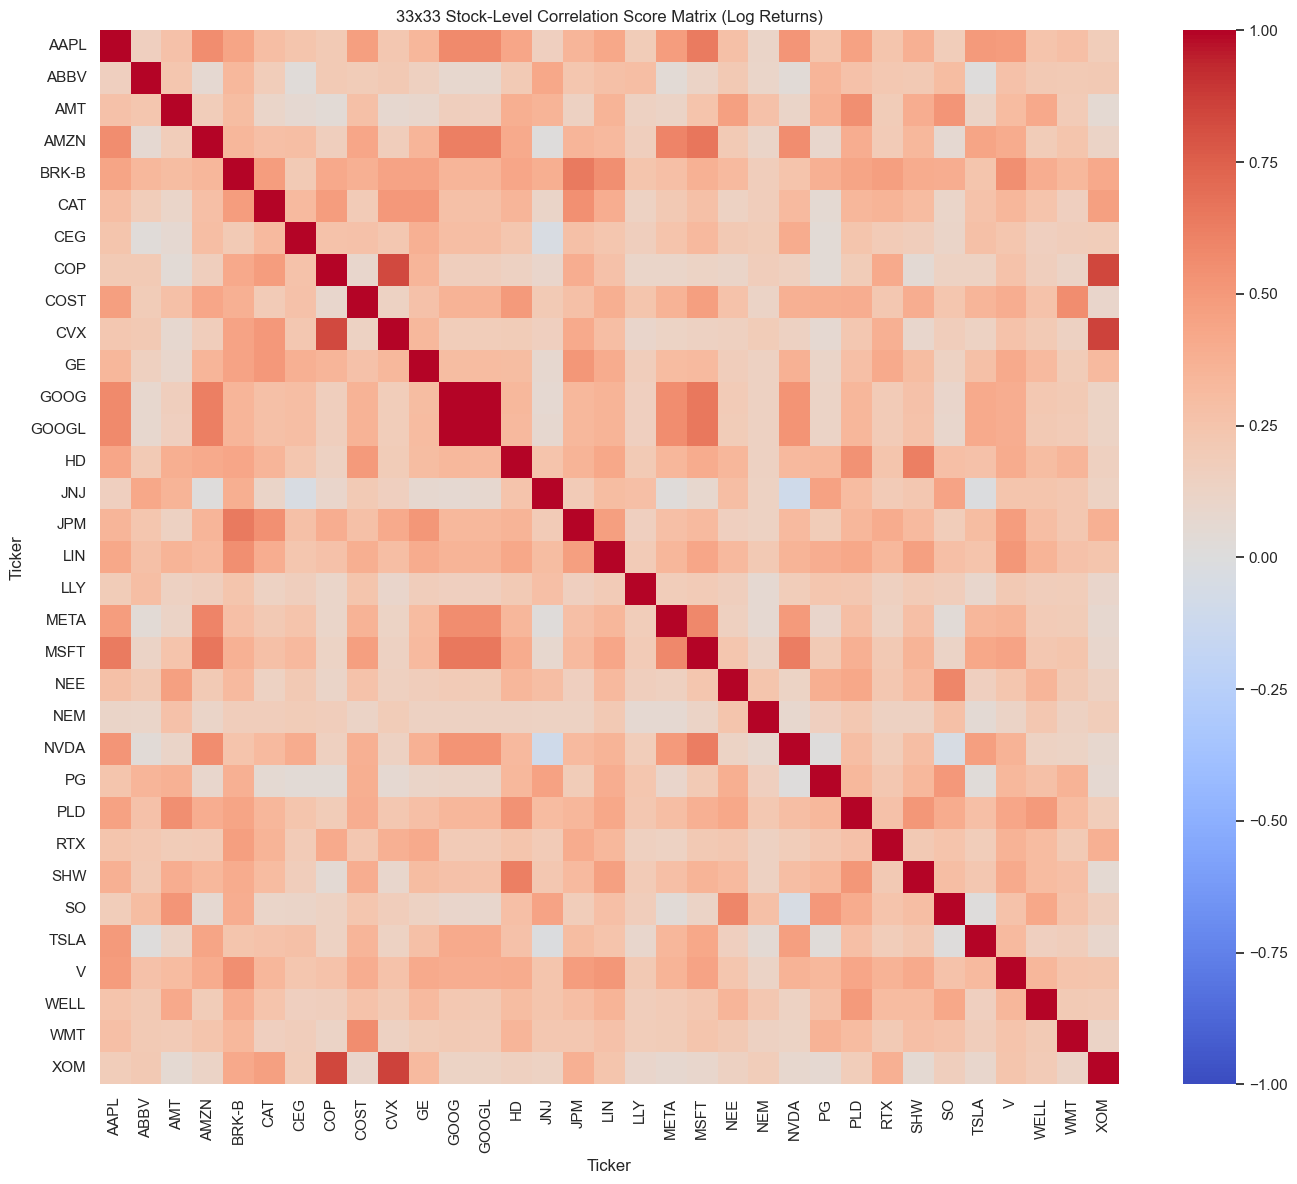

In [143]:
# --- Compute and save 33x33 stock-level correlation score matrix ---
# Pivot daily log returns to wide format (Date x Symbol)
returns_wide = sp500_subset2.pivot(index="Date", columns="Symbol", values="LogReturn").sort_index()
# Drop dates where all tickers are NaN
returns_wide = returns_wide.dropna(how="all")

# Compute stock-level correlation matrix (33x33)
stock_corr_matrix = returns_wide.corr().values
np.save("stock_corr_matrix.npy", stock_corr_matrix)

print("Stock-level correlation matrix shape:", stock_corr_matrix.shape)

# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns
tickers = returns_wide.columns.tolist()
plt.figure(figsize=(14, 12))
sns.heatmap(stock_corr_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=tickers, yticklabels=tickers)
plt.title("33x33 Stock-Level Correlation Score Matrix (Log Returns)")
plt.xlabel("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

In [144]:
# Find the pair of tickers with the highest off-diagonal correlation
import numpy as np
import pandas as pd

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Mask diagonal
mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
corr_flat = corr_matrix[mask]
max_corr = np.max(corr_flat)

# Find indices of highest correlation
max_idx = np.where(corr_matrix == max_corr)
pairs = [(i, j) for i, j in zip(*max_idx) if i != j]
if pairs:
    i, j = pairs[0]
    print(f"Highest correlation: {max_corr:.3f} between {tickers[i]} and {tickers[j]}")
else:
    print("No off-diagonal correlations found.")

Highest correlation: 0.995 between GE and GOOG
